## Import libraries

In [1]:
import matplotlib
#matplotlib.use('Agg')
import matplotlib.pyplot as plt

import os
from astropy.table import Table
from astropy.cosmology import FlatwCDM
import emcee
import numpy as np
import corner
import scipy.optimize as op
import pandas as pd

## HOME DEFINITION

In [11]:
HOME = os.path.expanduser("~") + '/gdrive/DataHII/'

## Data adquisition

In [12]:
def h2gdat(dpath):
    tpath = dpath + 'indat/h2data.dat'
    data = Table.read(tpath, format='ascii')

    vx = data['col4']
    vxErr = data['col5']
    vy = data['col6']
    vyErr = data['col7']
    vz = data['col2']
    vzErr = data['col3']
    return vx, vxErr, vy, vyErr, vz, vzErr

In [14]:
# Main Code
#mcd = os.path.dirname(os.path.abspath(__file__))

dpath = HOME + 'MCMC/EMCEE/dat/'

# Reading Data
vx, vxErr, vy, vyErr, vz, vzErr = h2gdat(dpath)

In [15]:
data = {'Id': np.arange(0,189,1),
        r'F(H$\beta$)': vy,
        r'Error F(H$\beta$)': vyErr,
        r'$\sigma$': vx,
        r'Error $\sigma$': vxErr,
        r'$z$': vz,
        r'Error $z$': vzErr}
DF = pd.DataFrame(data)
DF[r'We $z$'] = (DF[r'Error $z$'] / DF[r'$z$'] ) * 100

#plt.hist(DF['$z$'], bins = 100)
GEHR = DF[DF['$z$'] > 10]
len(GEHR)
HIIG = DF[DF['$z$'] < 10]
#plt.hist(HIIG['$z$'], bins = 100)
len(HIIG)
#plt.bar(np.arange(1,154,1),HIIG[r'Error $z$'])

153

In [6]:
'''

plt.errorbar( x = HIIG[r'$\sigma$'][HIIG['$z$'] < 0.5] ,
             y = HIIG[r'F(H$\beta$)'][HIIG['$z$'] <0.5], 
             xerr = HIIG[r'Error $\sigma$'][HIIG['$z$'] < 0.5] , 
             yerr = HIIG[r'Error F(H$\beta$)'][HIIG['$z$'] < 0.5],
            fmt = '.')
plt.errorbar( x = HIIG[r'$\sigma$'][HIIG['$z$'] > 0.5] ,
             y = HIIG[r'F(H$\beta$)'][HIIG['$z$']  > 0.5], 
             xerr = HIIG[r'Error $\sigma$'][HIIG['$z$'] > 0.5] , 
             yerr = HIIG[r'Error F(H$\beta$)'][HIIG['$z$'] > 0.5],
            fmt = '.')
plt.errorbar( x = GEHR[r'$\sigma$'] ,
             y = GEHR[r'F(H$\beta$)'], 
             xerr = GEHR[r'Error $\sigma$'] , 
             yerr = GEHR[r'Error F(H$\beta$)'],
            fmt = '.')

'''

"\n\nplt.errorbar( x = HIIG[r'$\\sigma$'][HIIG['$z$'] < 0.5] ,\n             y = HIIG[r'L(H$\x08eta$)'][HIIG['$z$'] <0.5], \n             xerr = HIIG[r'Error $\\sigma$'][HIIG['$z$'] < 0.5] , \n             yerr = HIIG[r'Error L(H$\x08eta$)'][HIIG['$z$'] < 0.5],\n            fmt = '.')\nplt.errorbar( x = HIIG[r'$\\sigma$'][HIIG['$z$'] > 0.5] ,\n             y = HIIG[r'L(H$\x08eta$)'][HIIG['$z$']  > 0.5], \n             xerr = HIIG[r'Error $\\sigma$'][HIIG['$z$'] > 0.5] , \n             yerr = HIIG[r'Error L(H$\x08eta$)'][HIIG['$z$'] > 0.5],\n            fmt = '.')\nplt.errorbar( x = GEHR[r'$\\sigma$'] ,\n             y = GEHR[r'L(H$\x08eta$)'], \n             xerr = GEHR[r'Error $\\sigma$'] , \n             yerr = GEHR[r'Error L(H$\x08eta$)'],\n            fmt = '.')\n\n"

## F(x)'s

In [16]:
def lnlike(theta, x, y, z, xerr, yerr, zerr):
    alpha, beta, h0, Om, w0 = theta

    cosmo = FlatwCDM(H0=h0*100, Om0=Om, w0=w0)
    ixG = np.where(z > 10)
    ixH = np.where(z < 10)

    Mum = z*0.0
    MumErr = z*0.0

    Mum[ixG] = z[ixG]
    MumErr[ixG] = zerr[ixG]

    Mum[ixH] = 5.0*np.log10(cosmo.luminosity_distance(z[ixH]).value) + 25.0
    MumErr[ixH] = (5.0/np.log(10.0))*(zerr[ixH]/z[ixH])

    Mu = 2.5*(beta*x + alpha) - 2.5*y - 100.195
    MuErr = 2.5*np.sqrt((yerr)**2 + beta**2*(xerr)**2)

    R = (Mu - Mum)
    W = 1.0/(MuErr**2 + MumErr**2)

    xsq = np.sum(R**2*W)
    llq = -0.5*xsq
    return (llq, xsq, R, Mum)
def lnprior(theta):
    alpha, beta, h0, Om, w0 = theta
    if (0.0 <= beta <= 10.0 and 20.0 <= alpha <= 40.0 and 0.5 <= h0 <= 1.0
            and 0.0 <= Om <= 1.0 and -2.0 <= w0 <= 0.0):
        return 0.0
    return -np.inf
def lnprob(theta, x, y, z, xerr, yerr, zerr):
    lp = lnprior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + lnlike(theta, x, y, z, xerr, yerr, zerr)[0]

## Sample

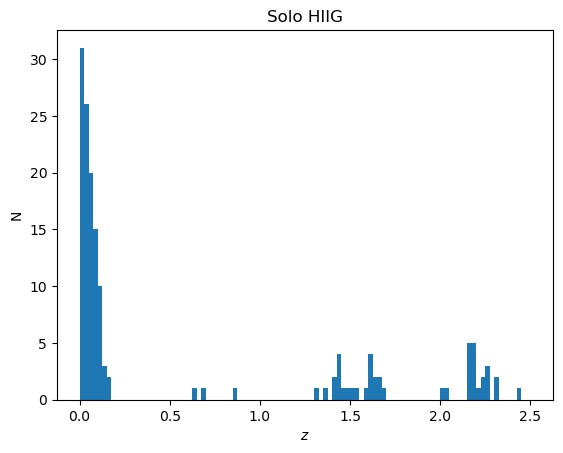

In [17]:
sample = DF[((DF['$z$'] >= 0.0) & (DF['$z$'] <= 0.5)) | (DF['$z$'] > 10)] # Redshift para HIIG menor a 0.5
plt.hist(DF['$z$'], bins = 100, range = [0,2.5])
plt.title('Solo HIIG')
plt.xlabel(r'$z$')
plt.ylabel(r'N')
plt.show()

In [18]:
new_sample = Table.from_pandas(sample) #Definicion de la muestra que tomara MCMC

In [19]:
# First guess
ialpha = 33.0
ibeta = 5.0
ih0 = 0.7
iOm = 0.3
iw0 = -1.0

In [20]:
# Maximum Likelihood
nll = lambda *args: -lnlike(*args)[0]
result = op.minimize(nll, [ialpha, ibeta, ih0,iOm,iw0],
                    args=(new_sample[r'$\sigma$'],
                        new_sample[r'F(H$\beta$)'],
                        new_sample[r'$z$'],
                        new_sample[r'Error $\sigma$'],
                        new_sample[r'Error F(H$\beta$)'],
                        new_sample[r'Error $z$']))
alpha_ml, beta_ml, h0_ml, iOm_ml, iw0_ml = result["x"]

print('max llq')
print(alpha_ml)
print(beta_ml)
print(h0_ml)
print(iOm_ml)
print(iw0_ml)

/tmp/ipykernel_10773/47896359.py:14: RuntimeWarning: invalid value encountered in log10
  Mum[ixH] = 5.0*np.log10(cosmo.luminosity_distance(z[ixH]).value) + 25.0


ValueError: Om0 cannot be negative.

## MCMC

In [21]:
# MCMC
ndim, nwalkers = 5, 100
pos = [[ialpha, ibeta, ih0, iOm, iw0] + 1e-5*np.random.randn(ndim)
       for i in range(nwalkers)]

In [22]:
sampler = emcee.EnsembleSampler(nwalkers, ndim, lnprob,
                                args=(new_sample[r'$\sigma$'], 
                                      new_sample[r'F(H$\beta$)'],
                                      new_sample[r'$z$'],
                                      new_sample[r'Error $\sigma$'],
                                      new_sample[r'Error F(H$\beta$)'],
                                      new_sample[r'Error $z$']),
                                threads=16)

In [23]:
# Run 100 steps as a burn-in.
pos, prob, state = sampler.run_mcmc(pos, 100)

In [24]:
# Reset the chain to remove the burn-in samples.
sampler.reset()

# Starting from the final position in the burn-in chain
sampler.run_mcmc(pos, 1000, rstate0=state)

print("Mean acceptance fraction: {0:.3f}"
      .format(np.mean(sampler.acceptance_fraction)))

samples = sampler.flatchain
lnprob = sampler.flatlnprobability

Mean acceptance fraction: 0.459


In [25]:
alpha_mcmc, beta_mcmc, h0_mcmc, Om_mcmc, w0_mcmc = map(
                                 lambda v: (v[1], v[2]-v[1], v[1]-v[0]),
                                 zip(*np.percentile(samples, [16, 50, 84],
                                                    axis=0)))

## Corner

In [26]:
print('mcmc')
print(alpha_mcmc)
print(beta_mcmc)
print(h0_mcmc)
print(Om_mcmc)
print(w0_mcmc)
print(len(vx))

# Plot
path = dpath+'results/trploth0.pdf'

mcmc
(33.34225287264137, 0.14217956825591926, 0.1511211628986331)
(4.942479358785177, 0.12418570574724885, 0.1169136942964446)
(0.7335836479048142, 0.042254964620100255, 0.043462399051088396)
(0.6501257937082812, 0.2492542432857876, 0.3760692174555742)
(-0.7083366978460588, 0.5227468841356897, 0.7595540891192161)
189


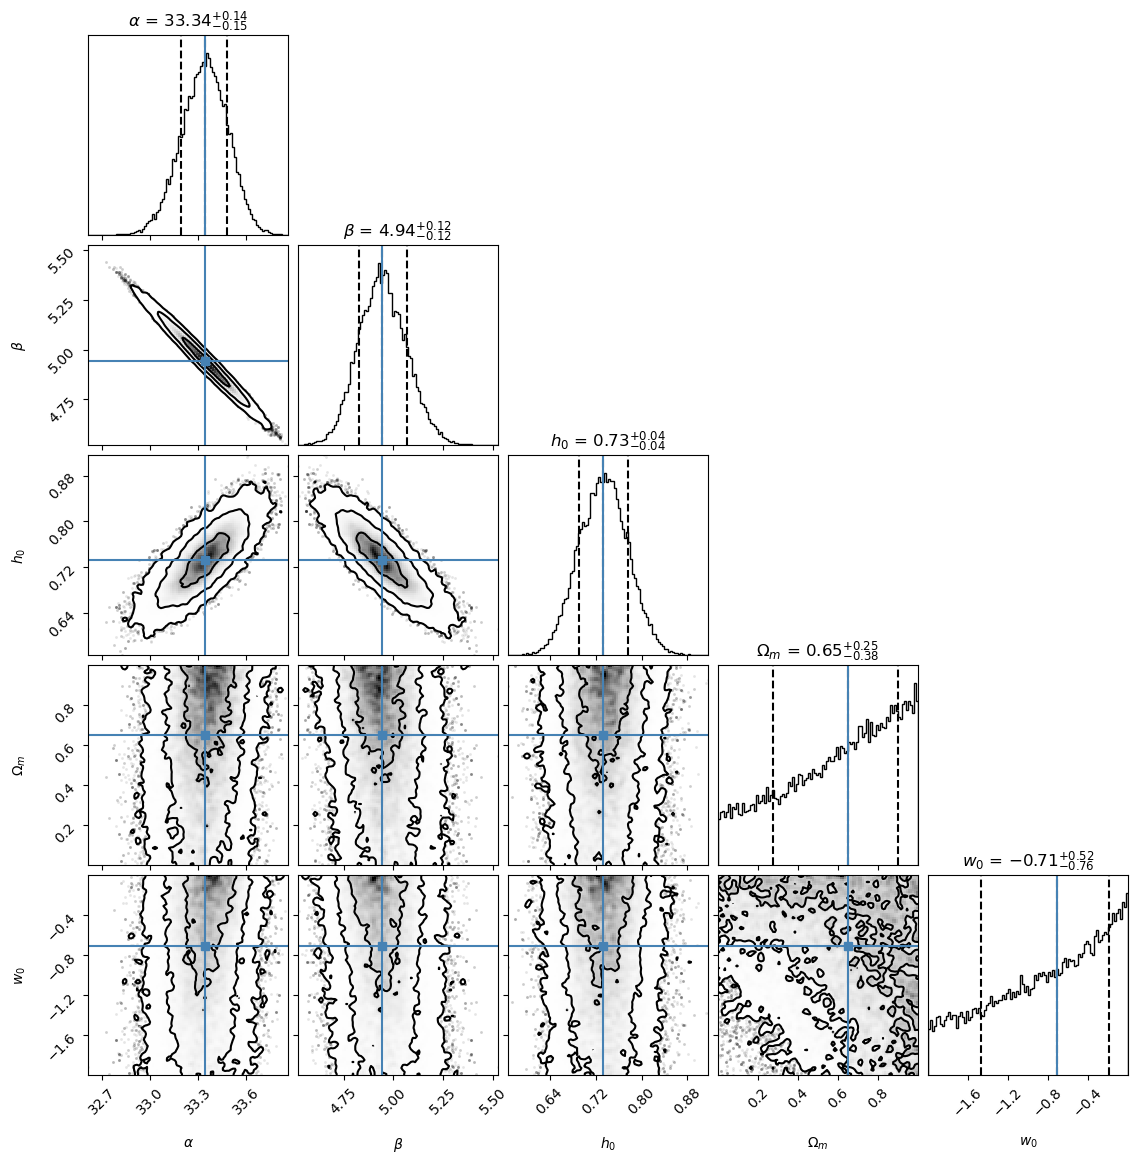

In [27]:

fig = corner.corner(samples,
                    labels=["$\\alpha$", "$\\beta$", "$h_0$", "$\Omega_m$",
                            "$w_0$"],
                    truths=[alpha_mcmc[0],  beta_mcmc[0], h0_mcmc[0],
                            Om_mcmc[0], w0_mcmc[0]],
                    quantiles=[0.16, 0.50, 0.84],
                    plot_contours='true',
                    levels=1.0 - np.exp(
                        -0.5 * np.arange(1.0, 3.1, 1.0) ** 2),
                    smooth=1.0,
                    bins=100,
                    color='black',
                    show_titles=1)
plt.savefig(path)